### 전국 문화시설 자료 정리

In [1]:
import pandas as pd

# 각 CSV 파일 읽기
df1 = pd.read_csv('1국립도서관.csv')
df2 = pd.read_csv('2공공도서관.csv')
df3 = pd.read_csv('3박물관.csv')
df4 = pd.read_csv('4미술관.csv')
df5 = pd.read_csv('5생활문화센터.csv')
df6 = pd.read_csv('6문예회관.csv')
df7 = pd.read_csv('7지방문화원.csv')
df8 = pd.read_csv('8문화의집.csv')
df9 = pd.read_csv('9문학관.csv')

# 각 데이터프레임에서 필요한 열만 추출
df1_selected = df1[['시도', '이용자수(명)']].rename(columns={'이용자수(명)': '이용자수'})
df2_selected = df2[['시도', '이용자수(명)']].rename(columns={'이용자수(명)': '이용자수'})
df3_selected = df3[['시도', '연관람인원(명)']].rename(columns={'연관람인원(명)': '이용자수'})
df4_selected = df4[['시도', '연관람인원(명)']].rename(columns={'연관람인원(명)': '이용자수'})
df5_selected = df5[['시도', '연간이용자수(명)']].rename(columns={'연간이용자수(명)': '이용자수'})
df6_selected = df6[['시도', '총이용자수']].rename(columns={'총이용자수': '이용자수'})
df7_selected = df7[['시도', '연간참여자수(단위:명)']].rename(columns={'연간참여자수(단위:명)': '이용자수'})
df8_selected = df8[['시도', '연간이용자수(명)']].rename(columns={'연간이용자수(명)': '이용자수'})
df9_selected = df9[['시도', '연간방문인원(명)']].rename(columns={'연간방문인원(명)': '이용자수'})

# 각 데이터프레임에 문화시설 유형을 추가
df1_selected['시설'] = '국립도서관'
df2_selected['시설'] = '공공도서관'
df3_selected['시설'] = '박물관'
df4_selected['시설'] = '미술관'
df5_selected['시설'] = '생활문화센터'
df6_selected['시설'] = '문예회관'
df7_selected['시설'] = '지방문화원'
df8_selected['시설'] = '문화의집'
df9_selected['시설'] = '문학관'

In [2]:
# 모든 데이터프레임을 하나로 합치기
df_all = pd.concat([df1_selected, df2_selected, df3_selected, df4_selected, df5_selected,
                    df6_selected, df7_selected, df8_selected, df9_selected])

# '이용자수' 열을 숫자로 변환하고, 변환할 수 없는 값은 NaN으로 처리
df_all['이용자수'] = pd.to_numeric(df_all['이용자수'], errors='coerce')

In [3]:
# '시도' 열 정리: 문자열로 변환 후 공백 및 특수 문자 제거
df_all['시도'] = df_all['시도'].astype(str).str.strip()

# 대소문자 통일 (필요 시)
df_all['시도'] = df_all['시도'].str.upper()  # 모든 값 대문자로 변환

# 시도별로 각 문화시설의 개수와 이용자수 합 계산
df_facility_count = df_all.groupby(['시도', '시설']).size().unstack(fill_value=0)
df_facility_user_sum = df_all.groupby(['시도', '시설']).agg(
    이용자수_합=('이용자수', 'sum')
).unstack(fill_value=0)

In [4]:
# 9개의 주요 시설만 필터링
시설명_목록 = ['국립도서관', '공공도서관', '박물관', '미술관', '생활문화센터', '문예회관', '지방문화원', '문화의집', '문학관']
facility_count_filtered = df_facility_count[시설명_목록]
df_facility_user_sum_filtered = df_facility_user_sum['이용자수_합'][시설명_목록]

# 시설 개수를 결합
df_grouped = pd.concat([facility_count_filtered], axis=1)

# 총이용자수 계산: 각 시도의 모든 시설의 이용자수 합
df_grouped['총이용자수'] = df_facility_user_sum_filtered.sum(axis=1)

# 총문화시설수 계산: 각 시도별로 9개 시설의 개수를 합산
df_grouped['총문화시설수'] = df_grouped[시설명_목록].sum(axis=1)

# 최종 결과 출력
df_grouped = df_grouped.reset_index()

# 결과 확인
print(df_grouped[['시도', '국립도서관', '공공도서관', '박물관', '미술관', '생활문화센터', '문예회관', '지방문화원', '문화의집', '문학관', '총문화시설수', '총이용자수']])


시설  시도  국립도서관  공공도서관  박물관  미술관  생활문화센터  문예회관  지방문화원  문화의집  문학관  총문화시설수  \
0   강원      0     61  100   21      18    23     18     4    1     246   
1   경기      1    309  129   59      23    45     31    11    2     610   
2   경남      0     79   78   10      12    22     20     8    6     235   
3   경북      0     71   77   11      16    27     23     5    2     232   
4   광주      0     27   13   14       8     8      5     3    0      78   
5   대구      0     44   17    4      11    11      8     0    0      95   
6   대전      0     25   15    5       2     5      5     3    1      61   
7   부산      0     51   33    9      20    12     16     0    3     144   
8   서울      3    199  136   49      11    29     25     4    0     456   
9   세종      0     15    7    0       2     1      1     0    0      26   
10  울산      0     20   10    1       3     6      5     0    1      46   
11  인천      0     58   30    5      10    12     10     0    2     127   
12  전남      0     73   63   41      13

In [5]:
# 최종 결과를 CSV로 저장
df_grouped.to_csv("최종_문화시설.csv", index=False, encoding='utf-8-sig')

### 시도 별 총문화시설의 분포

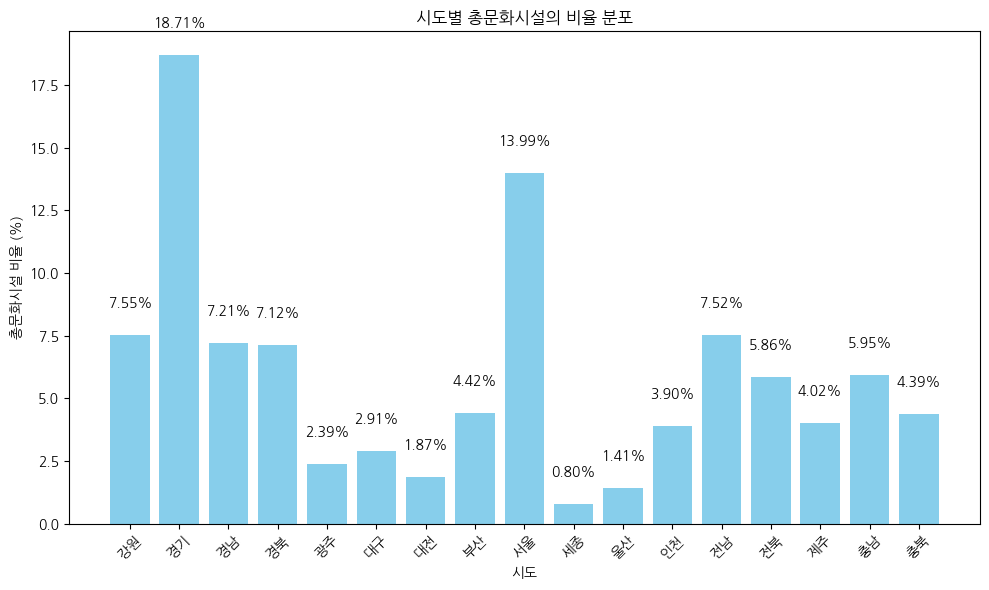

In [6]:
import matplotlib.pyplot as plt
from matplotlib import rc

# 나눔고딕 폰트 설정
rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 각 시도의 총문화시설수의 합을 구하고, 그 값으로 비율을 계산
df_grouped['비율'] = (df_grouped['총문화시설수'] / df_grouped['총문화시설수'].sum()) * 100

# 그래프 그리기
plt.figure(figsize=(10, 6))

# 막대 그래프 그리기
bars = plt.bar(df_grouped['시도'], df_grouped['비율'], color='skyblue')

# 그래프 레이블 설정
plt.xlabel('시도')
plt.ylabel('총문화시설 비율 (%)')
plt.title('시도별 총문화시설의 비율 분포')

# x축 눈금 회전
plt.xticks(rotation=45)

# 그래프 레이아웃 조정
plt.tight_layout()

# 비율을 각 막대 위에 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f'{height:.2f}%', 
             ha='center', va='bottom', fontsize=10)

# 그래프 출력
plt.show()

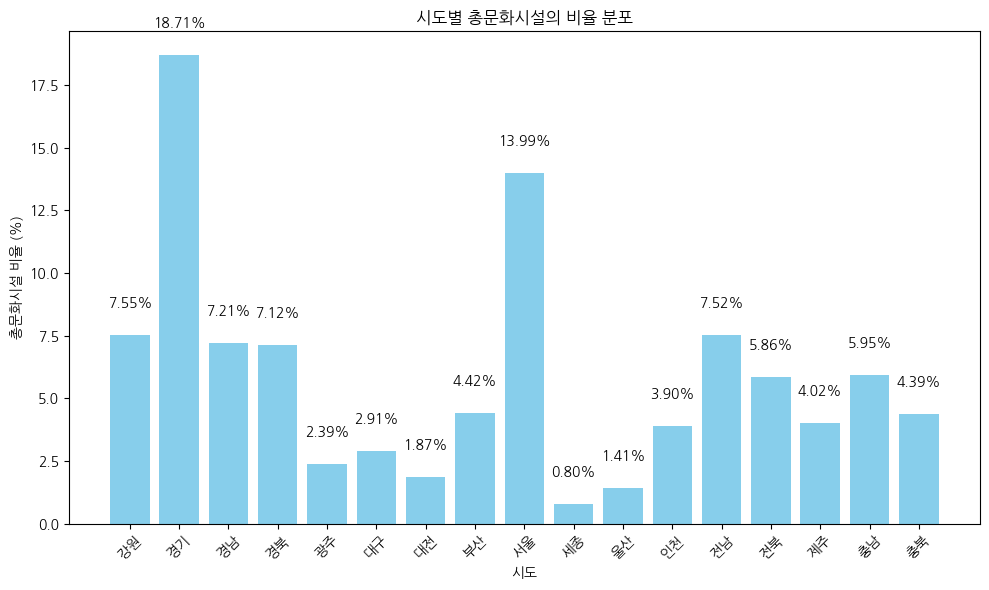

In [6]:
import matplotlib.pyplot as plt
from matplotlib import rc

# 나눔고딕 폰트 설정
rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

file_path = "최종_문화시설.csv"
df = pd.read_csv(file_path)

# 시도를 가나다순으로 정렬
df = df.sort_values(by='시도')

# 비율 계산
df['비율'] = (df['총문화시설수'] / df['총문화시설수'].sum()) * 100

# 그래프 그리기
plt.figure(figsize=(10, 6))

# 막대 그래프 그리기
bars = plt.bar(df['시도'], df['비율'], color='skyblue')

# 그래프 레이블 설정
plt.xlabel('시도')
plt.ylabel('총문화시설 비율 (%)')
plt.title('시도별 총문화시설의 비율 분포')

# x축 눈금 회전
plt.xticks(rotation=45)

# 그래프 레이아웃 조정
plt.tight_layout()

# 비율을 각 막대 위에 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f'{height:.2f}%', 
             ha='center', va='bottom', fontsize=10)

# 그래프 출력
plt.show()

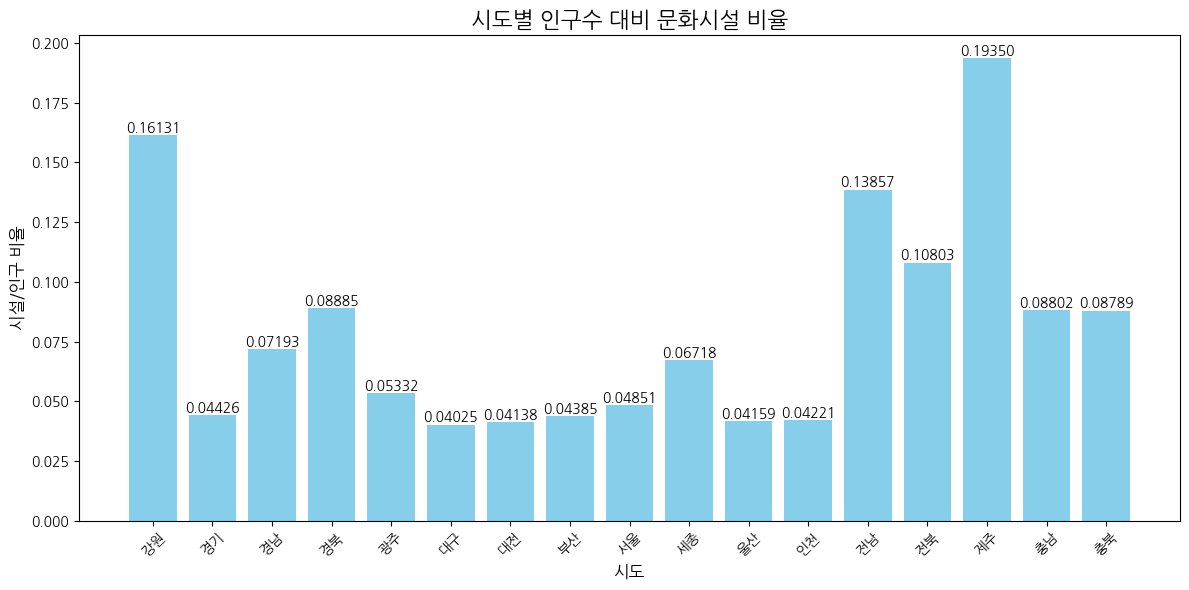

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc

# 나눔고딕 폰트 설정
rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
file_path = "최종_문화시설.csv"
df = pd.read_csv(file_path)

# 시도별 인구수 데이터 추가
population_data = {
    "서울": 9400, "부산": 3284, "대구": 2360, "인천": 3009, "광주": 1463,
    "대전": 1474, "울산": 1106, "세종": 387, "경기": 13781, "강원": 1525,
    "충북": 1627, "충남": 2204, "전북": 1768, "전남": 1768, "경북": 2611,
    "경남": 3267, "제주": 677
}

# 인구수 컬럼 추가
df['인구수'] = df['시도'].map(population_data)

# 문화시설수 대비 인구수 비율 계산 (문화시설수 / 인구수)
df['시설/인구 비율'] = df['총문화시설수'] / df['인구수']

# 시도를 가나다순으로 정렬
df = df.sort_values(by='시도')

# 그래프 그리기
plt.figure(figsize=(12, 6))

# 막대 그래프 그리기
bars = plt.bar(df['시도'], df['시설/인구 비율'], color='skyblue')

# 그래프 레이블 설정
plt.xlabel('시도', fontsize=12)
plt.ylabel('시설/인구 비율', fontsize=12)
plt.title('시도별 인구수 대비 문화시설 비율', fontsize=16)

# x축 눈금 회전
plt.xticks(rotation=45)

# 그래프 레이아웃 조정
plt.tight_layout()

# 비율을 각 막대 위에 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.0001, f'{height:.5f}', 
             ha='center', va='bottom', fontsize=10)

# 그래프 출력
plt.show()


### 시도 별 여가활동 월평균 지출액

        ID  여가활동 지출액(월평균)  여가시설 만족도  시도
0  1003001         300000       NaN  서울
1  1003002         500000       NaN  서울
2  1003003         350000       NaN  서울
3  1003004         300000       NaN  서울
4  1003021         100000       NaN  서울


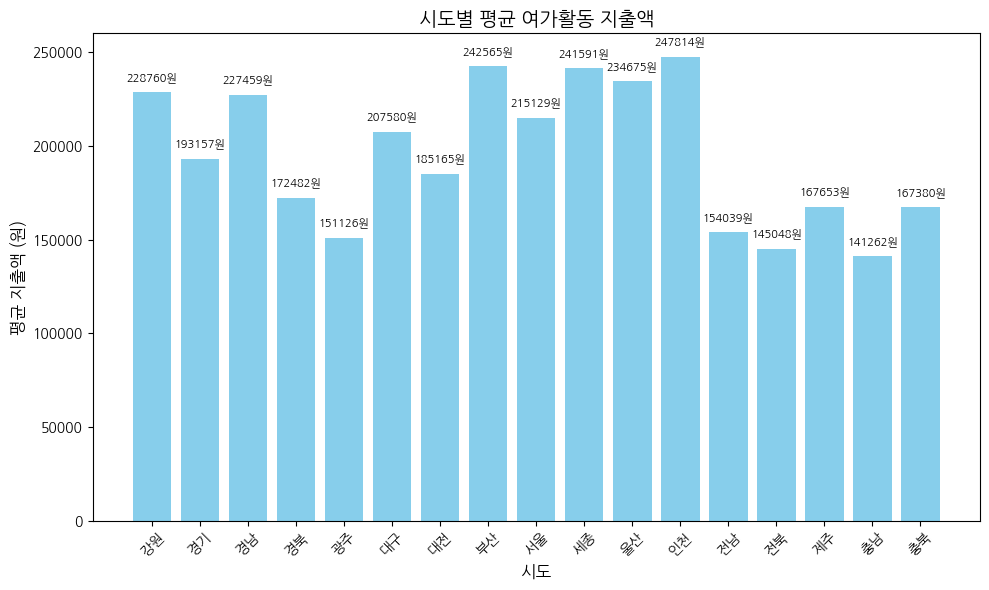

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc

# 데이터 불러오기
file_path = "국민여가활동조사(정리+).csv"
data = pd.read_csv(file_path)

# 데이터 확인
print(data.head())

# 나눔고딕 폰트 설정
rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 결측치 처리
data = data.dropna(subset=['여가활동 지출액(월평균)'])

# 시도별 평균 계산
avg_expense_by_city = data.groupby('시도')['여가활동 지출액(월평균)'].mean()

# 시도 가나다순 정렬
avg_expense_by_city = avg_expense_by_city.sort_index()

# 시각화
plt.figure(figsize=(10, 6))
bars = plt.bar(avg_expense_by_city.index, avg_expense_by_city.values, color='skyblue')

# 막대 위에 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 5000, f'{height:.0f}원',
             ha='center', va='bottom', fontsize=8)

# 그래프 설정
plt.title("시도별 평균 여가활동 지출액", fontsize=14)
plt.ylabel("평균 지출액 (원)", fontsize=12)
plt.xlabel("시도", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# 그래프 출력
plt.show()

### 시도 별 여가시설 만족도

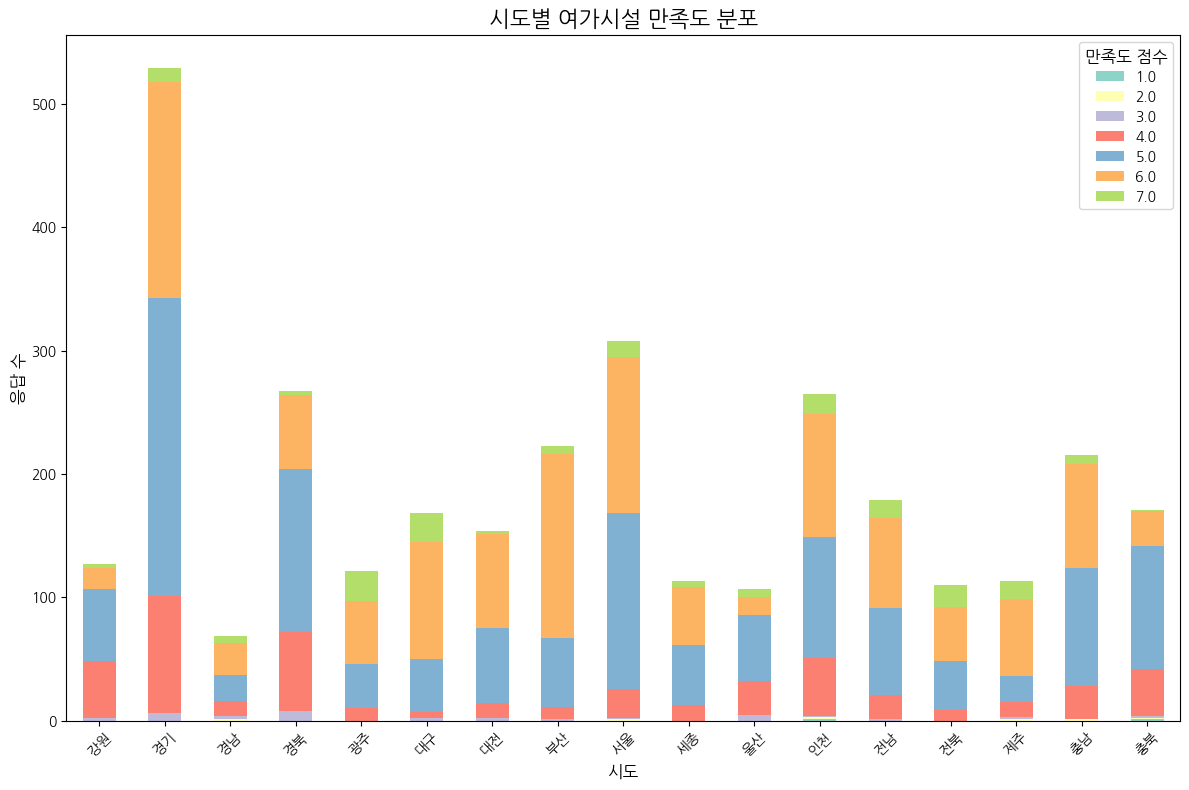

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
import locale

# 한글 정렬 설정
locale.setlocale(locale.LC_ALL, 'ko_KR.UTF-8')

# 데이터 불러오기
file_path = "국민여가활동조사(정리+).csv"
data = pd.read_csv(file_path)

# 나눔고딕 폰트 설정
rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 결측치 제거 ('여가시설 만족도'가 결측치인 경우 제외)
data = data.dropna(subset=['여가시설 만족도'])

# 시도별 만족도 점수 개수 집계
satisfaction_counts = data.groupby(['시도', '여가시설 만족도']).size().unstack(fill_value=0)

# 한글 사전순으로 시도 정렬
satisfaction_counts = satisfaction_counts.reindex(sorted(satisfaction_counts.index, key=locale.strxfrm))

# 색상 팔레트 설정 (Matplotlib 내장 팔레트 사용)
palette = plt.cm.Set3.colors  # Set3 팔레트 선택

# 시각화
satisfaction_counts.plot(kind='bar', stacked=True, figsize=(12, 8), color=palette[:len(satisfaction_counts.columns)])
plt.title("시도별 여가시설 만족도 분포", fontsize=16)
plt.xlabel("시도", fontsize=12)
plt.ylabel("응답 수", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="만족도 점수", fontsize=10, title_fontsize=12)
plt.tight_layout()

# 그래프 출력
plt.show()

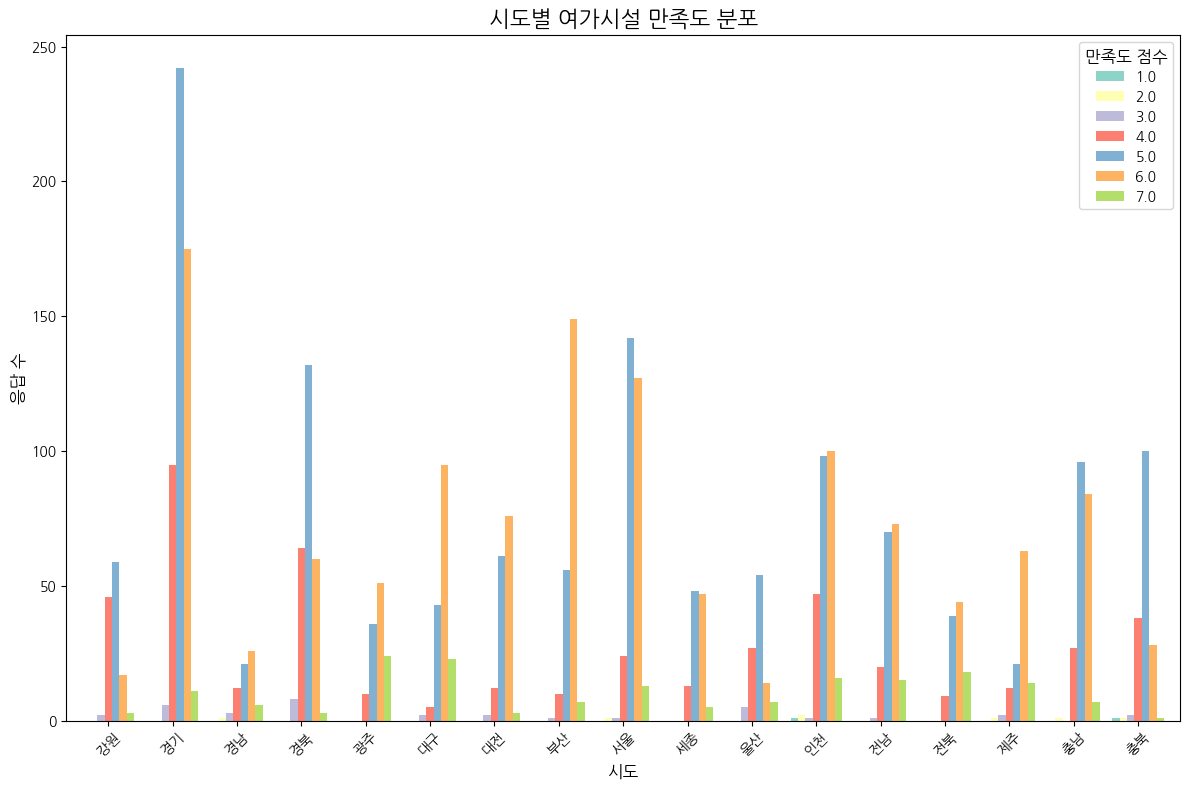

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
import locale

# 한글 정렬 설정
locale.setlocale(locale.LC_ALL, 'ko_KR.UTF-8')

# 데이터 불러오기
file_path = "국민여가활동조사(정리+).csv"
data = pd.read_csv(file_path)

# 나눔고딕 폰트 설정
rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 결측치 제거 ('여가시설 만족도'가 결측치인 경우 제외)
data = data.dropna(subset=['여가시설 만족도'])

# 시도별 만족도 점수 개수 집계
satisfaction_counts = data.groupby(['시도', '여가시설 만족도']).size().unstack(fill_value=0)

# 한글 사전순으로 시도 정렬
satisfaction_counts = satisfaction_counts.reindex(sorted(satisfaction_counts.index, key=locale.strxfrm))

# 색상 팔레트 설정 (Matplotlib 내장 팔레트 사용)
palette = plt.cm.Set3.colors  # Set3 팔레트 선택

# 시각화
ax = satisfaction_counts.plot(kind='bar', figsize=(12, 8), color=palette[:len(satisfaction_counts.columns)], width=0.8)

# 그래프 제목과 레이블 설정
plt.title("시도별 여가시설 만족도 분포", fontsize=16)
plt.xlabel("시도", fontsize=12)
plt.ylabel("응답 수", fontsize=12)

# x축 눈금 회전
plt.xticks(rotation=45)

# 범례 설정
plt.legend(title="만족도 점수", fontsize=10, title_fontsize=12)

# 그래프 레이아웃 조정
plt.tight_layout()

# 그래프 출력
plt.show()

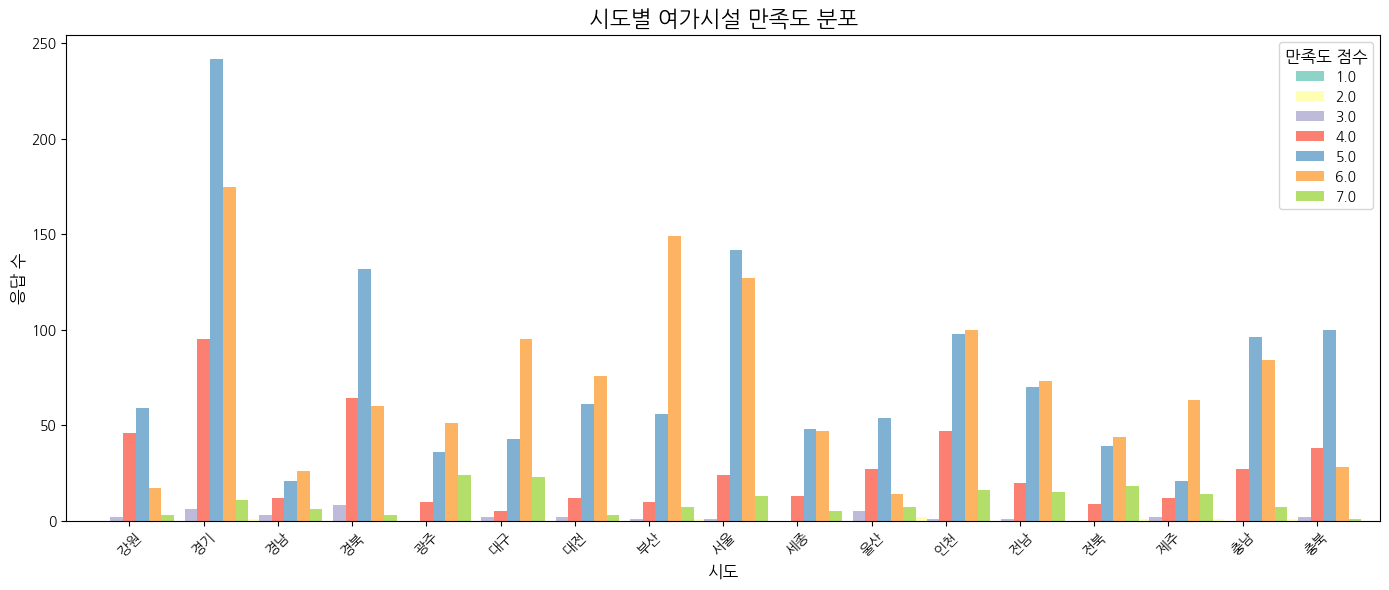

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
import locale

# 한글 정렬 설정
locale.setlocale(locale.LC_ALL, 'ko_KR.UTF-8')

# 데이터 불러오기
file_path = "국민여가활동조사(정리+).csv"
data = pd.read_csv(file_path)

# 나눔고딕 폰트 설정
rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 결측치 제거 ('여가시설 만족도'가 결측치인 경우 제외)
data = data.dropna(subset=['여가시설 만족도'])

# 시도별 만족도 점수 개수 집계
satisfaction_counts = data.groupby(['시도', '여가시설 만족도']).size().unstack(fill_value=0)

# 한글 사전순으로 시도 정렬
satisfaction_counts = satisfaction_counts.reindex(sorted(satisfaction_counts.index, key=locale.strxfrm))

# 색상 팔레트 설정 (Matplotlib 내장 팔레트 사용)
palette = plt.cm.Set3.colors  # Set3 팔레트 선택

# 시각화
ax = satisfaction_counts.plot(kind='bar', figsize=(14, 6), color=palette[:len(satisfaction_counts.columns)], width=1.2)

# 그래프 제목과 레이블 설정
plt.title("시도별 여가시설 만족도 분포", fontsize=16)
plt.xlabel("시도", fontsize=12)
plt.ylabel("응답 수", fontsize=12)

# x축 눈금 회전
plt.xticks(rotation=45)

# 범례 설정
plt.legend(title="만족도 점수", fontsize=10, title_fontsize=12)

# 그래프 레이아웃 조정
plt.tight_layout()

# 그래프 출력
plt.show()

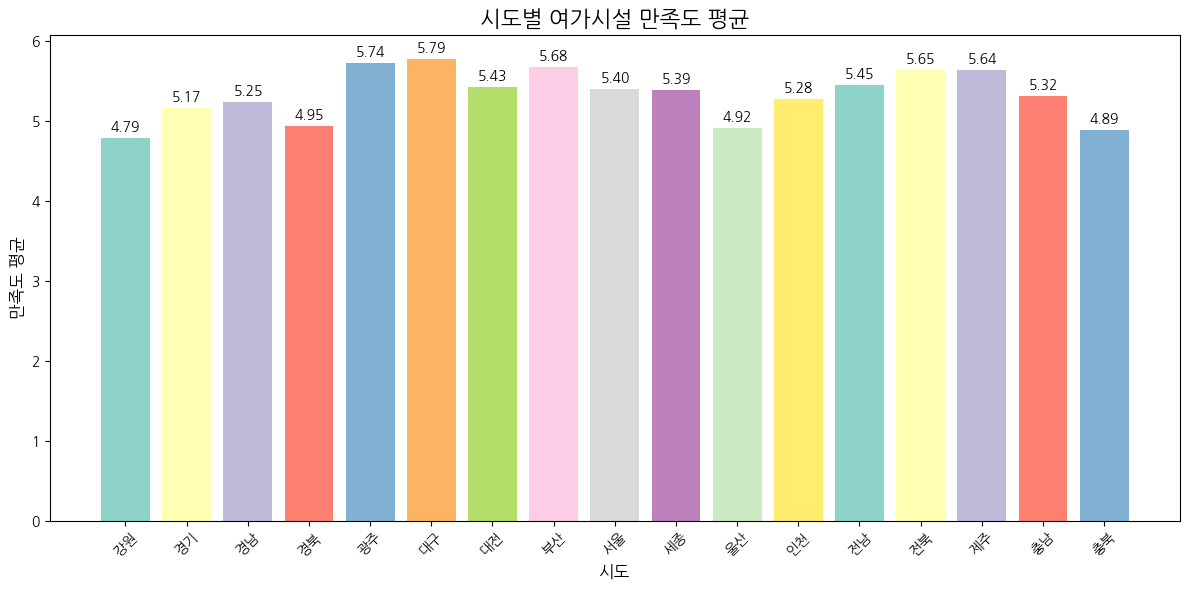

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
import locale

# 한글 정렬 설정
locale.setlocale(locale.LC_ALL, 'ko_KR.UTF-8')

# 데이터 불러오기
file_path = "국민여가활동조사(정리+).csv"
data = pd.read_csv(file_path)

# 나눔고딕 폰트 설정
rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 결측치 제거 ('여가시설 만족도'가 결측치인 경우 제외)
data = data.dropna(subset=['여가시설 만족도'])

# '여가시설 만족도'를 숫자로 변환
data['여가시설 만족도'] = pd.to_numeric(data['여가시설 만족도'], errors='coerce')

# 시도별 만족도 평균 계산
satisfaction_avg = data.groupby('시도')['여가시설 만족도'].mean()

# 한글 사전순으로 시도 정렬
satisfaction_avg = satisfaction_avg.sort_index(key=lambda x: sorted(x, key=locale.strxfrm))

# 색상 팔레트 설정 (Matplotlib 내장 팔레트 사용)
palette = plt.cm.Set3.colors  # Set3 팔레트 선택

# 시각화
plt.figure(figsize=(12, 6))
bars = plt.bar(satisfaction_avg.index, satisfaction_avg, color=palette[:len(satisfaction_avg)])

# 그래프 제목과 레이블 설정
plt.title("시도별 여가시설 만족도 평균", fontsize=16)
plt.xlabel("시도", fontsize=12)
plt.ylabel("만족도 평균", fontsize=12)

# x축 눈금 회전
plt.xticks(rotation=45)

# 막대 위에 평균 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.05, f'{height:.2f}', ha='center', va='bottom')

# 그래프 레이아웃 조정
plt.tight_layout()

# 그래프 출력
plt.show()